In [1]:
import pandas as pd
detecciones_csv = '/home/camilo/figuras_mauro/data/detecciones.csv'
df = pd.read_csv(detecciones_csv)
df = df[~df['site'].isin(['P.1078_SMM09333', 'P.209_SMM09576'])]
df['site'] = df['site'].str.replace('-', '_', regex=False)
df

,id,recording,site,year,month,day,hour,minute,species,songtype,...,x2,y1,y2,frequency,validated,url,score,site_id,presencia,datetime
0,627470889,SMM09557_20231009_185000.wav,P04_SMM09557,2023,10,9,18,50,Theristicus melanopis,Common Song,...,25.461333,796.875,2390.625,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.308460,48814,1,2023-10-09 18:50:00
1,627472690,SMM09721_20231003_111000.wav,P01_SMM09721,2023,10,3,11,10,Theristicus melanopis,Common Song,...,45.056000,796.875,2390.625,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.441862,48806,1,2023-10-03 11:10:00
2,627472802,SMM09499_20230929_195500.wav,P03_SMM09499,2023,9,29,19,55,Theristicus melanopis,Common Song,...,17.610667,796.875,2390.625,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.321300,48817,1,2023-09-29 19:55:00
3,627472819,SMM09261_20230928_160500.wav,P02_SMM09261,2023,9,28,18,5,Theristicus melanopis,Common Song,...,37.034667,796.875,2390.625,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.335424,49108,1,2023-09-28 18:05:00
4,627472873,SMM09499_20230928_160500.wav,P03_SMM09499,2023,9,28,16,5,Theristicus melanopis,Common Song,...,14.037333,796.875,2390.625,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.366723,48817,1,2023-09-28 16:05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23366,628235012,SMM09360_20231004_072500.wav,P23_SMM09360,2023,10,4,7,25,Turdus falcklandii,Common Song,...,12.736000,1359.375,9140.625,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.633157,48816,1,2023-10-04 07:25:00
23367,628235013,SMM09360_20231004_151500.wav,P23_SMM09360,2023,10,4,15,15,Turdus falcklandii,Common Song,...,36.650667,1359.375,9140.625,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.687807,48816,1,2023-10-04 15:15:00
23368,628235014,SMM09360_20231004_070500.wav,P23_SMM09360,2023,10,4,7,5,Turdus falcklandii,Common Song,...,56.448000,1359.375,9140.625,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.696696,48816,1,2023-10-04 07:05:00
23369,628235015,SMM09360_20231004_071000.wav,P23_SMM09360,2023,10,4,7,10,Turdus falcklandii,Common Song,...,6.560000,1359.375,9140.625,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.628169,48816,1,2023-10-04 07:10:00


In [11]:
import sweetviz as sv   

report = sv.analyze(df)

report.show_html('resumen_detecciones.html')

                                             |          | [  0%]   00:00 -> (? left)

Report resumen_detecciones.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [2]:
riqueza_csv = '~/figuras_mauro/data/riqueza_especies.csv'
df2 = pd.read_csv(riqueza_csv)
df2 = df2[~df2['site'].isin(['P.1078_SMM09333', 'P.209_SMM09576'])]
df2['site'] = df2['site'].str.replace('-', '_', regex=False)
df2

,datetime_5min,site,species_count
0,2023-09-28 00:00:00,P04_SMM09557,0
1,2023-09-28 00:00:00,P01_SMM09721,0
2,2023-09-28 00:00:00,P03_SMM09499,0
3,2023-09-28 00:00:00,P02_SMM09261,0
4,2023-09-28 00:00:00,P13_SMM09539,0
...,...,...,...
96763,2023-10-13 23:55:00,P35_SMM09330,0
96764,2023-10-13 23:55:00,P37_SMM09595,0
96765,2023-10-13 23:55:00,P41_SMM09350,0
96766,2023-10-13 23:55:00,P34_SMM09565,0


In [13]:
import sweetviz as sv   

report = sv.analyze(df2)

report.show_html('resumen_riqueza.html')

                                             |          | [  0%]   00:00 -> (? left)

Report resumen_riqueza.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## Respecto a las especies

Para estos análisis se utilizará el conjunto de datos de detecciones.

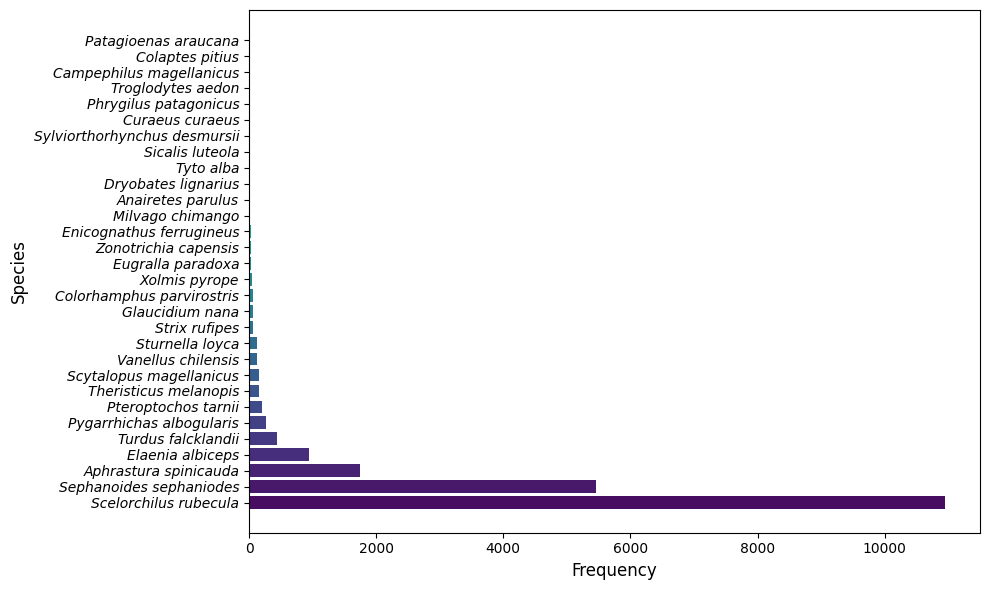

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Supón que tu dataframe se llama df
unique_species_count = df['species'].value_counts()
species = unique_species_count.index

palette = sns.color_palette("viridis", n_colors=len(species))

plt.figure(figsize=(10, 6))
plt.barh(unique_species_count.index, unique_species_count.values, color=palette)
#plt.title('Frecuencia de Especies', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Species', fontsize=12)
plt.yticks(fontstyle='italic', fontsize=10)
plt.tight_layout()
plt.show()


## Respecto al espacio

Para estos análisis se utilizará el conjunto de datos remuestrados cada 5 minutos, riqueza_especies

/tmp/ipykernel_21111/253954000.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='site', y='species_count', data=site_counts,


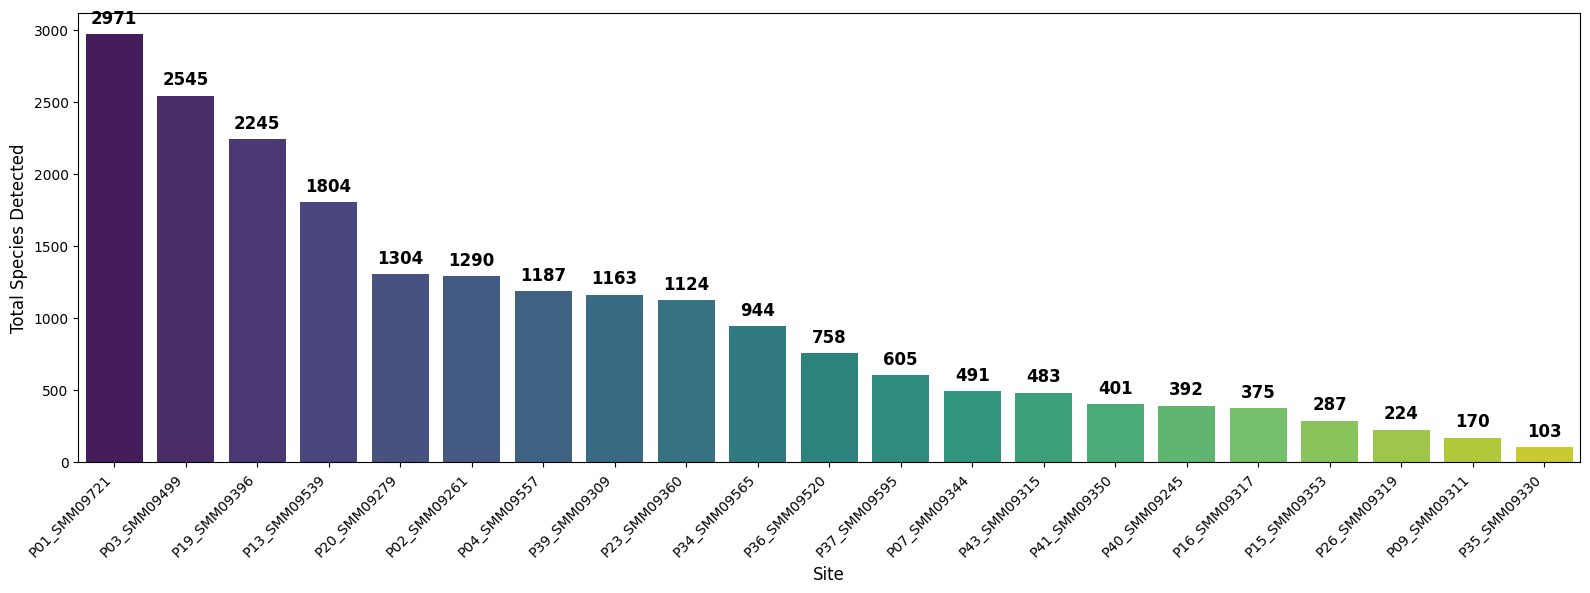

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar y ordenar
site_counts = df2.groupby('site', observed=True)['species_count'].sum().reset_index()
site_counts = site_counts.sort_values(by='species_count', ascending=False)

plt.figure(figsize=(16, 6))
ax = sns.barplot(x='site', y='species_count', data=site_counts,
                 order=site_counts['site'], palette="viridis")

#plt.title('Suma Total de Especies Detectadas por Sitio')
plt.xlabel('Site', fontsize=12)
plt.ylabel('Total Species Detected', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Agregar los valores encima de cada barra, usando los patches del gráfico
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 puntos arriba
                textcoords='offset points',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

## Respecto a la riqueza de especies x sitio

/tmp/ipykernel_21111/2527168994.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


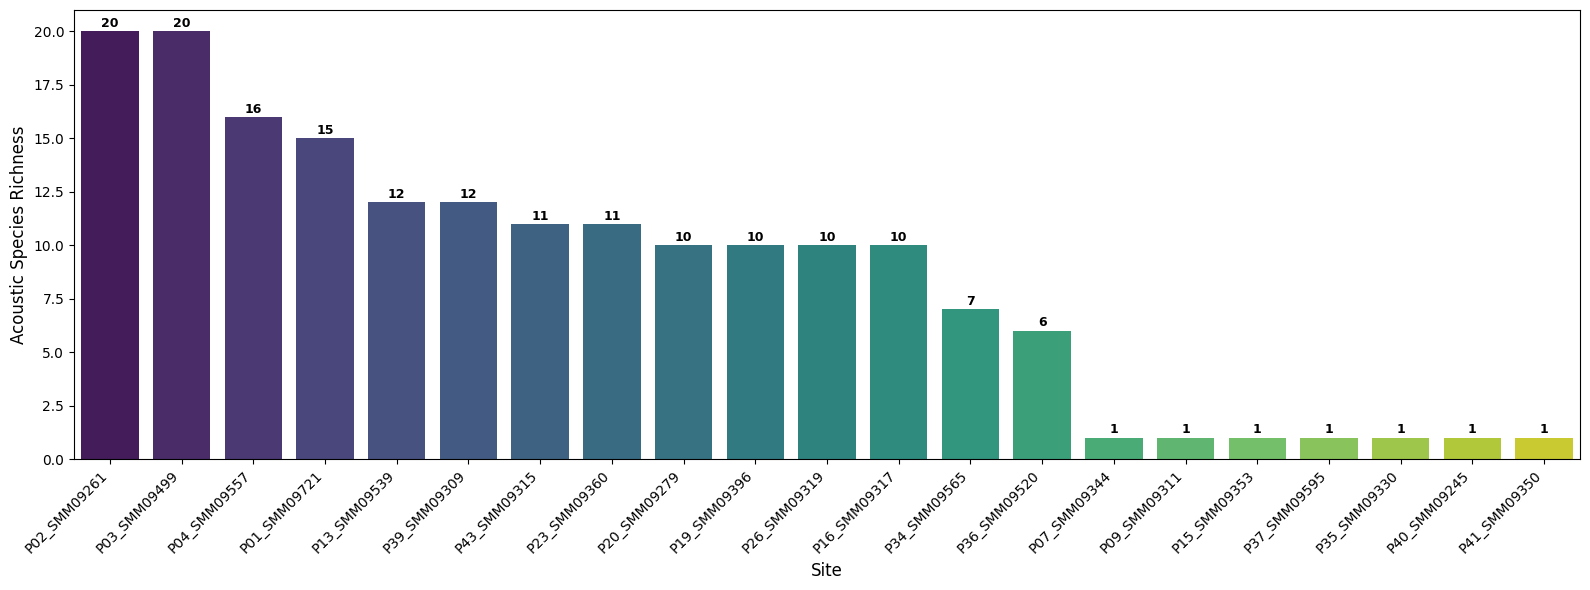

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# df es tu dataframe principal, el que tiene 'site' y 'species'
unique_species_per_site = df.groupby('site')['species'].nunique().sort_values(ascending=False)

plt.figure(figsize=(16, 6))
sns.barplot(
    x=unique_species_per_site.index,
    y=unique_species_per_site.values,
    palette="viridis"
)
for i, v in enumerate(unique_species_per_site.values):
    plt.text(i, v + 0.2, str(v), ha='center', fontsize=9, fontweight='bold')
#plt.title('Riqueza de Especies por Sitio', fontsize=16)
plt.xlabel('Site', fontsize=12)
plt.ylabel('Acoustic Species Richness', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Respecto a especies dominantes

Para estos análisis se utilizará el conjunto de datos remuestrados cada 5 minutos, riqueza_especies. Se filtrará para dejar solo a las tres especies con más detecciones, las cuales representan en conjunto el 85% de las detecciones totales. Estas especies son: Scelorchilus rubecula (50%), Sephanoides sephaniodes (23%) y Aphrastura spinicauda (12%).

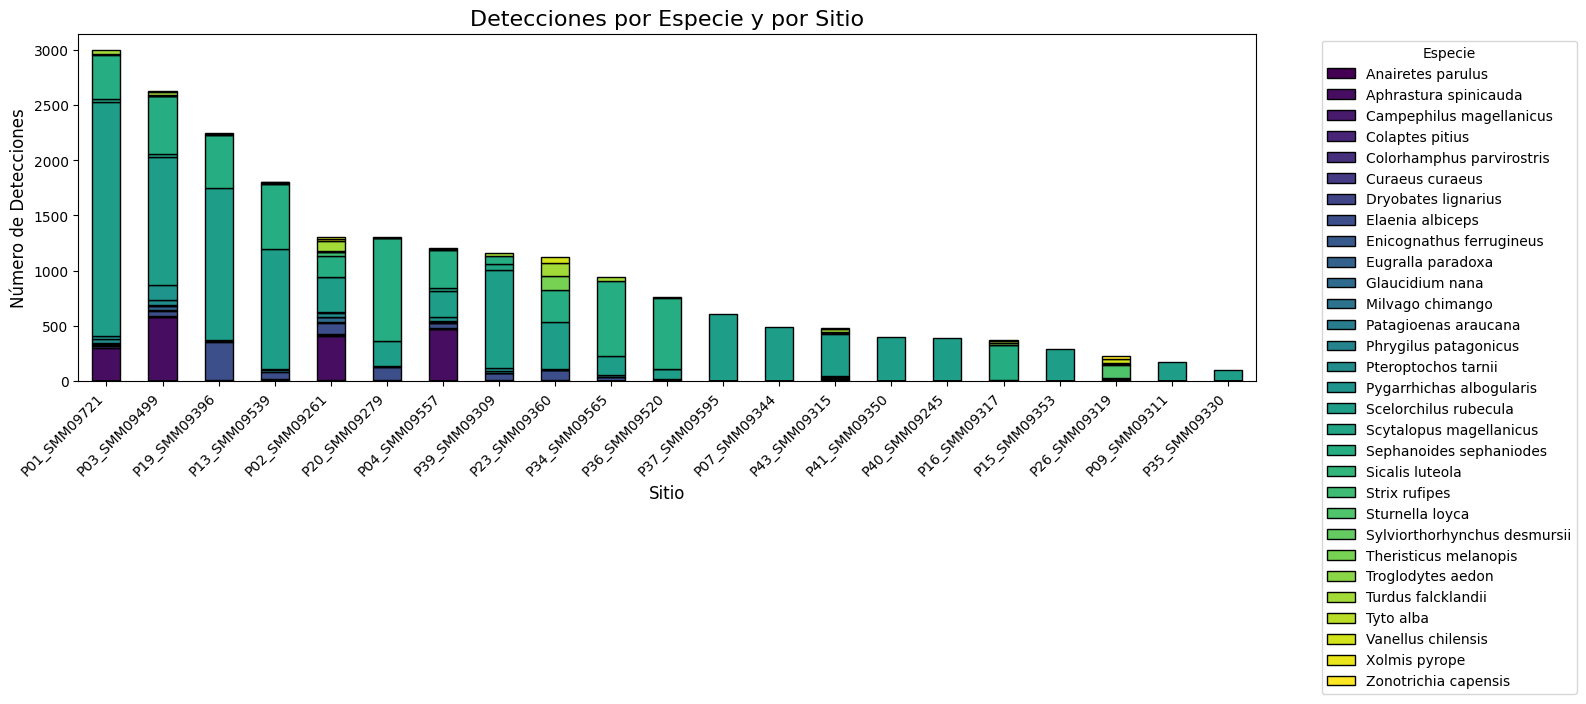

In [35]:
import pandas as pd

# Prepara tabla resumen: filas=site, columnas=species, valores=conteo
stacked_counts = df.groupby(['site', 'species']).size().unstack(fill_value=0)

# Ordena los sitios como quieras (por ejemplo, por suma total de detecciones)
ordered_sites = stacked_counts.sum(axis=1).sort_values(ascending=False).index
stacked_counts = stacked_counts.loc[ordered_sites]

# Gráfico de barras apiladas
stacked_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(16,6),
    colormap='viridis',  # cambiar colormap si tienes muchas especies
    edgecolor='black'
)
plt.title('Detecciones por Especie y por Sitio', fontsize=16)
plt.xlabel('Sitio', fontsize=12)
plt.ylabel('Número de Detecciones', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Especie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


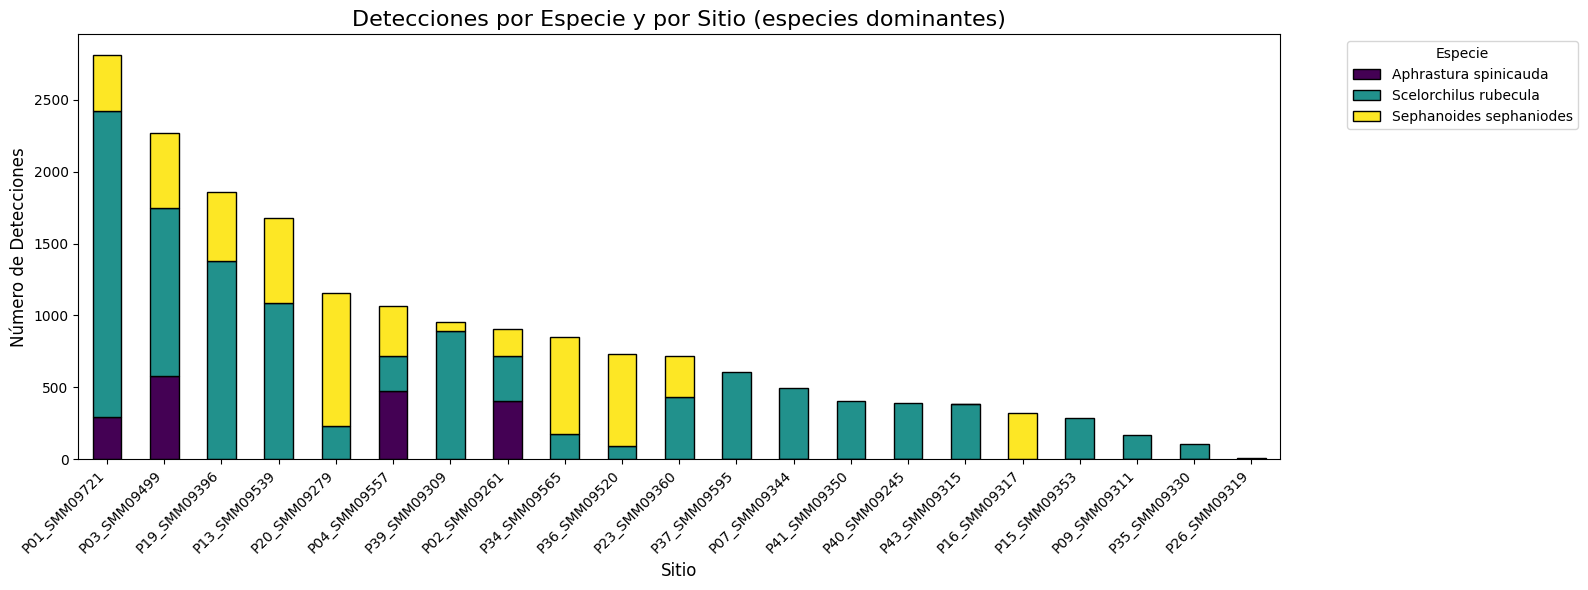

In [7]:
import matplotlib.pyplot as plt

# Filtrar el dataframe para incluir solo las especies deseadas
especies_filtradas = ['Scelorchilus rubecula', 'Sephanoides sephaniodes', 'Aphrastura spinicauda']
df_filtrado = df[df['species'].isin(especies_filtradas)]

# Crear tabla pivote: filas=site, columnas=species, valores=conteo
stacked_counts = df_filtrado.groupby(['site', 'species']).size().unstack(fill_value=0)

# Ordenar sitios según suma total de detecciones descendente
ordered_sites = stacked_counts.sum(axis=1).sort_values(ascending=False).index
stacked_counts = stacked_counts.loc[ordered_sites]

# Graficar barras apiladas
stacked_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(16,6),
    colormap='viridis',
    edgecolor='black'
)
plt.title('Detecciones por Especie y por Sitio (especies dominantes)', fontsize=16)
plt.xlabel('Sitio', fontsize=12)
plt.ylabel('Número de Detecciones', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Especie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


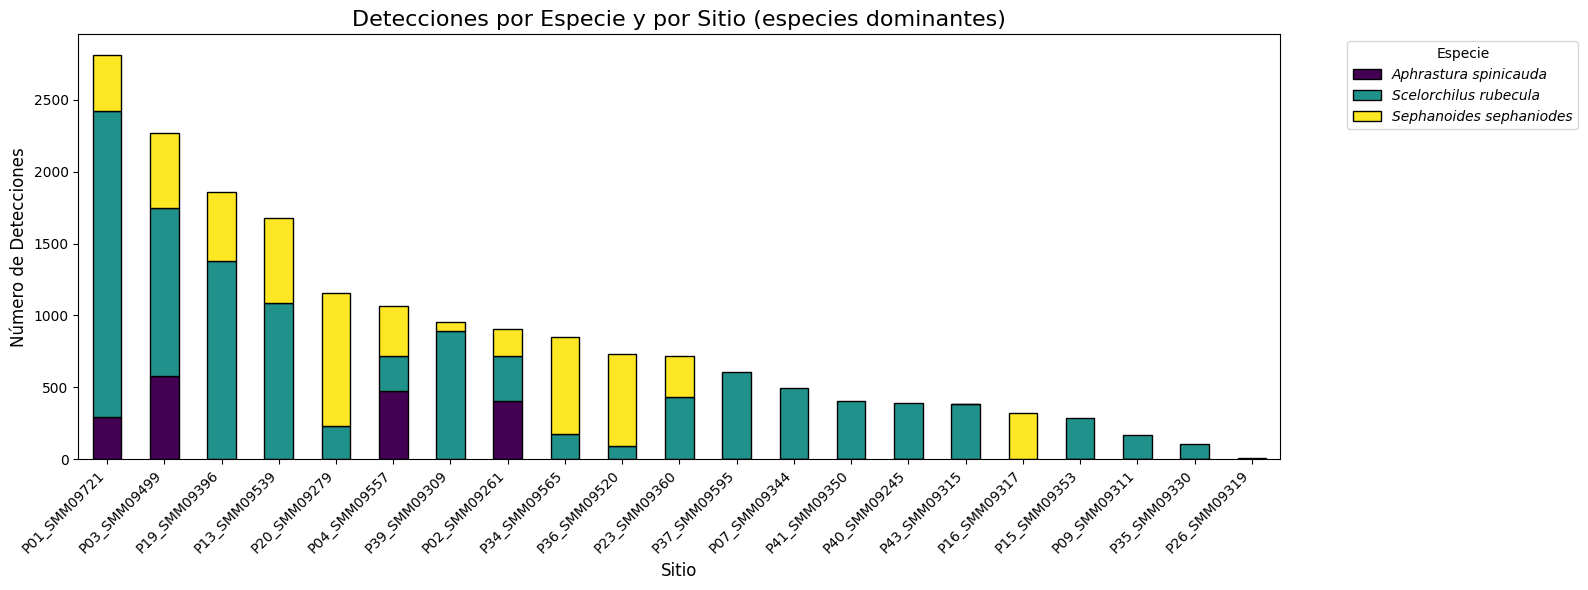

In [8]:
import matplotlib.font_manager as font_manager

# Definir la propiedad de fuente en cursiva
italic_font = font_manager.FontProperties(style='italic')

# Graficar barras apiladas
ax = stacked_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(16,6),
    colormap='viridis',
    edgecolor='black'
)

plt.title('Detecciones por Especie y por Sitio (especies dominantes)', fontsize=16)
plt.xlabel('Sitio', fontsize=12)
plt.ylabel('Número de Detecciones', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Aplicar la fuente en cursiva a las etiquetas de la leyenda
plt.legend(title='Especie', bbox_to_anchor=(1.05, 1), loc='upper left', prop=italic_font)

plt.tight_layout()
plt.show()


In [33]:
import pandas as pd
import plotly.graph_objects as go

# Conteo de detecciones por sitio y especie
counts = df.groupby(['site', 'species']).size().reset_index(name='detecciones')

# Ordenar sitios según suma total de detecciones (descendente)
site_order = counts.groupby('site')['detecciones'].sum().sort_values(ascending=False).index.tolist()

# Lista de especies únicas (orden original o alfabético)
species_unique = counts['species'].unique()

fig = go.Figure()

for sp in species_unique:
    sp_data = counts[counts['species'] == sp].set_index('site').reindex(site_order, fill_value=0).reset_index()
    fig.add_trace(go.Bar(
        x=sp_data['site'],
        y=sp_data['detecciones'],
        name=sp,
        # Aquí no se asigna marker_color para usar colores predeterminados
        hovertemplate='Sitio: %{x}<br>Especie: '+sp+'<br>Detecciones: %{y}<extra></extra>'
    ))

fig.update_layout(
    barmode='stack',
    xaxis=dict(
        categoryorder='array',
        categoryarray=site_order,
        tickangle=45,
        title='Sitio'
    ),
    yaxis=dict(title='Número de Detecciones'),
    legend_title_text='Especie',
    title='Detecciones por Especie y Sitio'
)

fig.show()



## Implementación Machine Learning
Para esta sección se utilizarán los registros de las especies que representan en conjunto el 85% de las detecciones totales. Estas especies son: Scelorchilus rubecula (50%), Sephanoides sephaniodes (23%) y Aphrastura spinicauda (12%).
Mediante el uso de Árboles de Decisiones se evaluará si exsiten efectos de las horas y/o sitios en la detección de estas especie.

In [86]:
# Preparar datos

import pandas as pd

file = '/home/camilo/data-science-lll/figuras_mauro/detecciones.csv'

df = pd.read_csv(file)
df = df[~df['site'].isin(['P.1078_SMM09333', 'P.209_SMM09576'])]


species_filtrar = ['Sephanoides sephaniodes', 'Scelorchilus rubecula', 'Aphrastura spinicauda']

df_filtrado = df[df['species'].isin(species_filtrar)]
df_filtrado['datetime'] = pd.to_datetime(df_filtrado['datetime'])


# Unificar separador en la columna 'site': reemplazar '-' por '_'
df_filtrado['site'] = df_filtrado['site'].str.replace('-', '_', regex=False)
df_filtrado


/tmp/ipykernel_40243/1543516471.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_40243/1543516471.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,id,recording,site,year,month,day,hour,minute,species,songtype,...,x2,y1,y2,frequency,validated,url,score,site_id,presencia,datetime
284,758768802,SMM09344_20231013_191000.wav,P07_SMM09344,2023,10,13,22,10,Scelorchilus rubecula,Common Song,...,6.645333,656.25,2062.5,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.427360,53982,1,2023-10-13 22:10:00
285,758768803,SMM09344_20231013_195000.wav,P07_SMM09344,2023,10,13,22,50,Scelorchilus rubecula,Common Song,...,43.840000,656.25,2062.5,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.521458,53982,1,2023-10-13 22:50:00
286,758768804,SMM09344_20231013_200000.wav,P07_SMM09344,2023,10,13,23,0,Scelorchilus rubecula,Common Song,...,3.893333,656.25,2062.5,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.599815,53982,1,2023-10-13 23:00:00
287,758768805,SMM09344_20231013_170000.wav,P07_SMM09344,2023,10,13,20,0,Scelorchilus rubecula,Common Song,...,3.424000,656.25,2062.5,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.508903,53982,1,2023-10-13 20:00:00
288,758768806,SMM09344_20231013_162000.wav,P07_SMM09344,2023,10,13,19,20,Scelorchilus rubecula,Common Song,...,3.850667,656.25,2062.5,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.423369,53982,1,2023-10-13 19:20:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22147,627472496,SMM09261_20230930_075000.wav,P02_SMM09261,2023,9,30,9,50,Aphrastura spinicauda,Common Song,...,12.832000,3937.50,6187.5,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.371336,49108,1,2023-09-30 09:50:00
22148,627472497,SMM09261_20230930_093500.wav,P02_SMM09261,2023,9,30,11,35,Aphrastura spinicauda,Common Song,...,37.472000,3937.50,6187.5,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.334635,49108,1,2023-09-30 11:35:00
22149,627472499,SMM09261_20230930_082000.wav,P02_SMM09261,2023,9,30,10,20,Aphrastura spinicauda,Common Song,...,37.066667,3937.50,6187.5,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.306531,49108,1,2023-09-30 10:20:00
22150,627472500,SMM09261_20230929_071500.wav,P02_SMM09261,2023,9,29,9,15,Aphrastura spinicauda,Common Song,...,51.701333,3937.50,6187.5,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.354636,49108,1,2023-09-29 09:15:00


In [88]:
# Extraer el código de sitio

import pandas as pd

df_filtrado['site_code'] = df_filtrado['site'].str.split('_').str[0]

/tmp/ipykernel_40243/3383782764.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [89]:
# Generar todas las combinaciones posibles de sitio y hora

import itertools

sites = df_filtrado['site_code'].unique()
hours = range(24)  # Horas del día de 0 a 23

all_combinations = pd.DataFrame(list(itertools.product(sites, hours)), columns=['site_code', 'hour'])

In [90]:
# Contar detecciones por sitio y hora para una especie específica

## Elegir la especie de interés
especie_objetivo = 'Scelorchilus rubecula', 

## Filtrar solo esa especie
df_esp = df_filtrado[df_filtrado['species'] == especie_objetivo]

## Contar detecciones por sitio y hora
detections = df_esp.groupby(['site_code', 'hour']).size().reset_index(name='count')

In [91]:
# Unir y rellenar ausencias con ceros

df_full = all_combinations.merge(detections, on=['site_code', 'hour'], how='left').fillna(0)
df_full['count'] = df_full['count'].astype(int)
df_full['presence'] = (df_full['count'] > 0).astype(int)

In [92]:
# Codificar variables categóricas para el modelo

## Codificar site_code como dummies (variables indicadoras)
df_model = pd.get_dummies(df_full, columns=['site_code'], drop_first=True)

In [93]:

df_model.head()

,hour,count,presence,site_code_P02,site_code_P03,site_code_P04,site_code_P07,site_code_P09,site_code_P13,site_code_P15,...,site_code_P23,site_code_P26,site_code_P34,site_code_P35,site_code_P36,site_code_P37,site_code_P39,site_code_P40,site_code_P41,site_code_P43
0,0,0,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,0,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,0,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3,0,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4,0,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Modelo

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Mejores hiperparámetros encontrados:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy en test con mejor modelo: 1.000

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       101

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



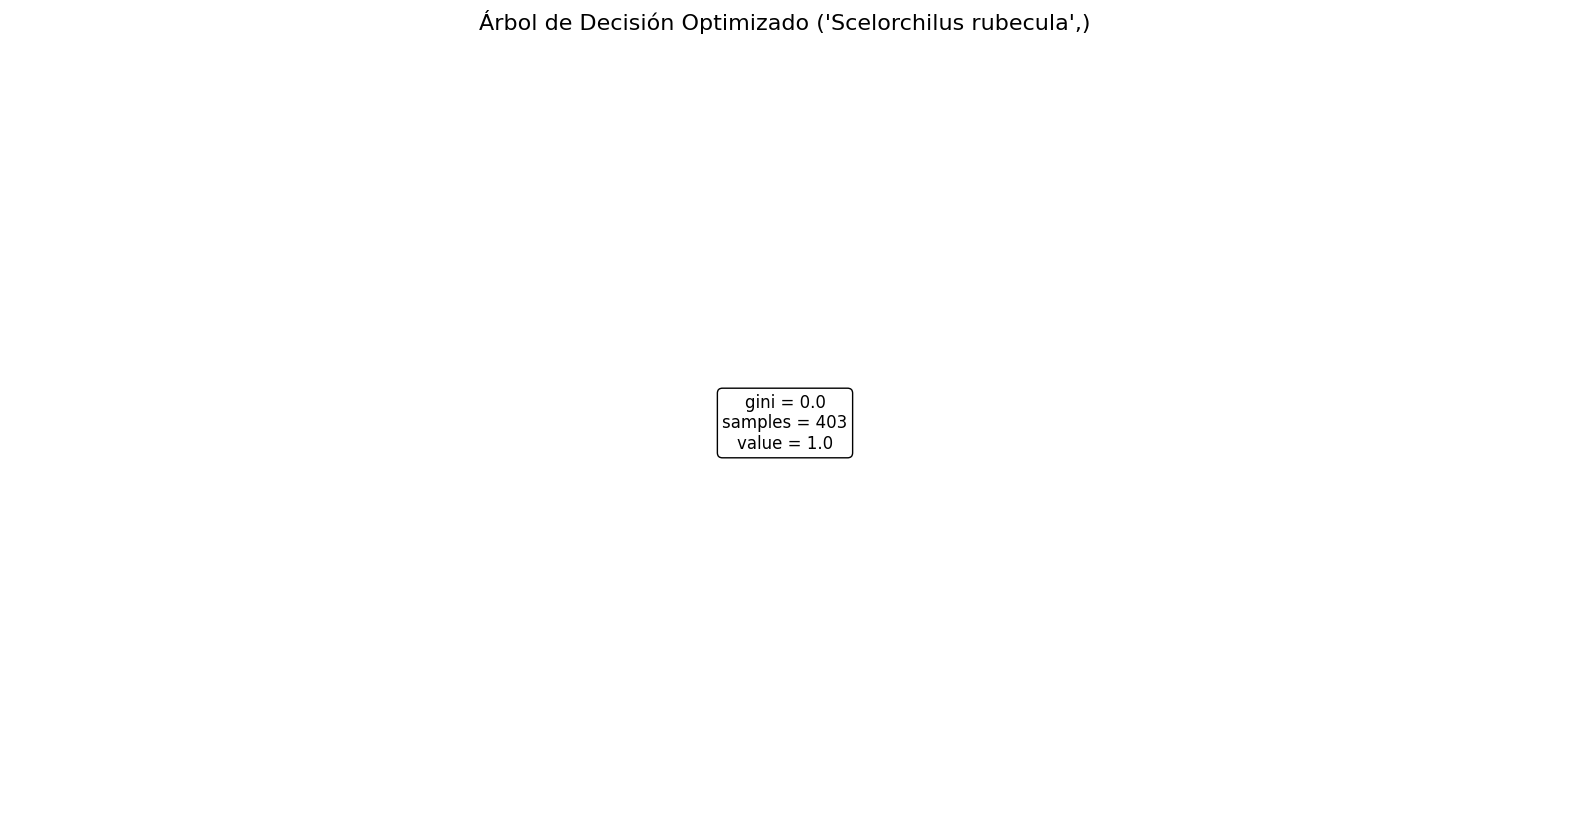

In [94]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Asumiendo df_model preparado con variables predictoras y target 'presence'
X = df_model.drop(columns=['count', 'presence'])
y = df_model['presence']

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir clasificador base
clf = DecisionTreeClassifier(random_state=42)

# Definir cuadrícula de hiperparámetros
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar GridSearchCV con validación cruzada
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

# Ejecutar búsqueda
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# Modelo optimizado
best_clf = grid_search.best_estimator_

# Evaluar en test
y_pred = best_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy en test con mejor modelo: {accuracy:.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# Visualizar árbol optimizado
plt.figure(figsize=(20,10))
plot_tree(
    best_clf,
    feature_names=X.columns,
    class_names=['Ausencia', 'Presencia'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title(f'Árbol de Decisión Optimizado {especie_objetivo}', fontsize=16)
plt.show()